EXPERIMENT 5.2: Moneyness Landscape and Advantage Threshold
S0=100.0, sigma=0.2, r=0.05, T=1.0, B=64, shots=8192, trials=20
Depth schedule: [0, 1, 3, 7, 15, 31, 63]

------------------------------------------------------------------------------------------
K=100 (0% OTM): V_BS=10.450584, V_disc=10.982046, p=0.09111, k_crit=4.62
  k= 0, cost=   8,192: MC=0.130572±0.025495, QAE=0.385344±0.059651, speedup=0.34x ***
  k= 1, cost=  24,576: MC=0.087816±0.015598, QAE=0.107789±0.014031, speedup=0.81x n.s.
  k= 3, cost=  57,344: MC=0.056797±0.010943, QAE=0.038294±0.006267, speedup=1.48x n.s.
  k= 7, cost= 122,880: MC=0.025118±0.006100, QAE=0.019276±0.004568, speedup=1.30x n.s.
  k=15, cost= 253,952: MC=0.022499±0.004824, QAE=0.008540±0.001280, speedup=2.63x *
  k=31, cost= 516,096: MC=0.016879±0.002177, QAE=0.004240±0.001035, speedup=3.98x ***
  k=63, cost=1,040,384: MC=0.015139±0.002864, QAE=0.002185±0.000335, speedup=6.93x ***
  → Best depth: k=63, speedup=6.93x, p-value=0.0002348 ***

------

/var/folders/yn/tp4d43ns64qb0vr9l2b390ym0000gn/T/ipykernel_16679/3226722805.py:540: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


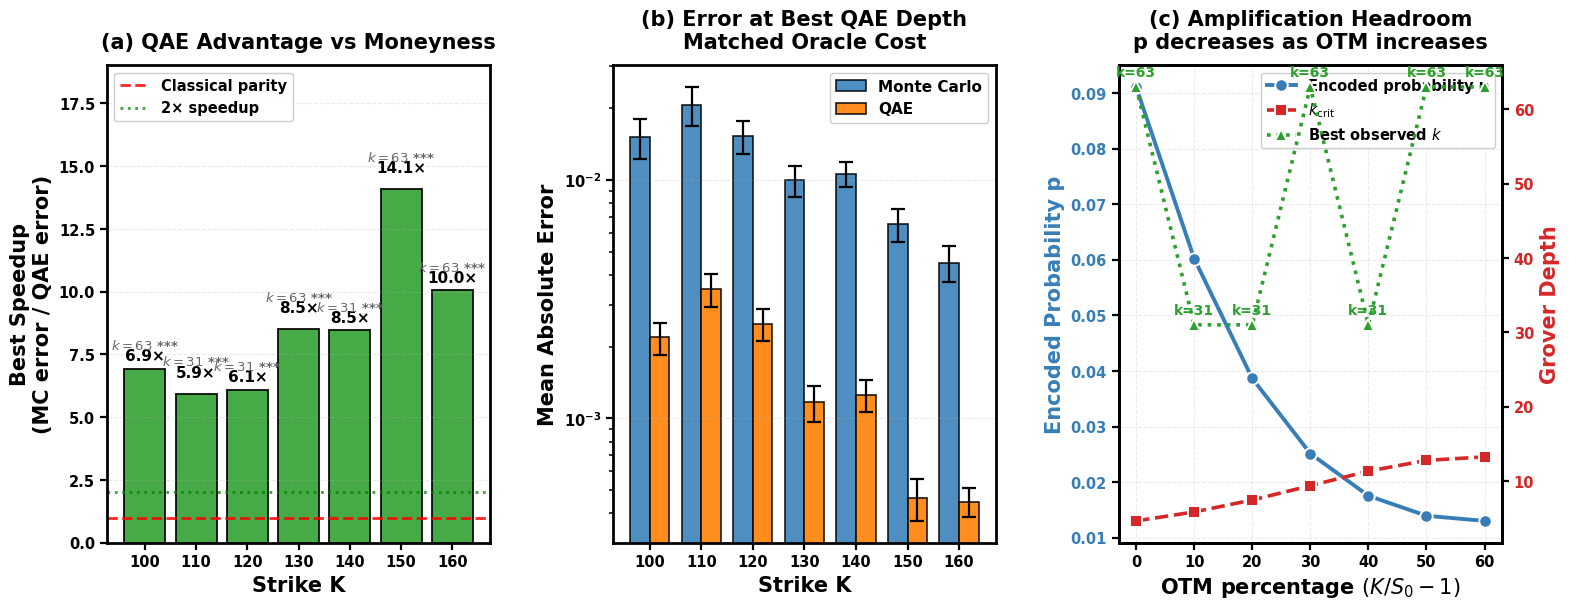


Saved: experiment_5_2_moneyness_landscape.pdf / .png


In [10]:
# ==============================================================================
# EXPERIMENT 5.2: Moneyness Landscape and Advantage Threshold
# Synthetic European call benchmark across ATM to deep OTM strikes.
#
# Purpose:
#   - Test how QAE advantage varies with option moneyness.
#   - For each strike, run the full QAE depth schedule.
#   - Compare QAE against Monte Carlo at matched oracle cost.
#   - Identify the best observed QAE speedup and the encoded-probability threshold
#     where statistically significant advantage emerges.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, ttest_ind
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)


def build_discrete_problem(S0, K, r, sigma, T, B=64, q_low=1e-6, q_high=1-1e-6):
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sigma_log = sigma * np.sqrt(T)

    quantiles = np.linspace(q_low, q_high, B+1)
    log_edges = norm.ppf(quantiles, loc=mu_log, scale=sigma_log)
    edges = np.exp(log_edges)

    centers = np.sqrt(edges[:-1] * edges[1:])
    cdf_edges = norm.cdf(log_edges, loc=mu_log, scale=sigma_log)

    probs = np.diff(cdf_edges)
    probs /= probs.sum()

    payoffs = np.maximum(centers - K, 0)
    V_disc = np.exp(-r*T) * np.sum(probs * payoffs)

    max_payoff = payoffs.max()

    if max_payoff == 0 or V_disc == 0:
        return None

    C = max_payoff * 1.2
    p = V_disc / (np.exp(-r*T) * C)

    # Compress large amplitudes to keep the encoded probability in a stable range.
    if p > 0.25:
        C = V_disc / (np.exp(-r*T) * 0.20)
        p = 0.20

    return type('Problem', (object,), {
        'V_disc': V_disc,
        'p': p,
        'C': C,
        'max_payoff': max_payoff,
        'centers': centers,
        'probs': probs,
        'payoffs': payoffs
    })()


def mc_estimator(centers, probs, K, r, T, N, seed=None):
    rng = np.random.default_rng(seed)
    ST = rng.choice(centers, size=N, p=probs)
    payoffs = np.maximum(ST - K, 0)
    return np.exp(-r*T) * np.mean(payoffs)


def run_QAE_Robust(p_true, k, shots, seed=None):
    """
    Corrected branch-aware QAE estimator.

    Circuit:
        RY(total_angle)|0>

    Measurement probability:
        P(1) = sin^2(total_angle / 2)

    Correct inverse branches:
        angle_measured
        2π - angle_measured

    The prior used here is the oracle prior p_true. This is therefore a validated
    baseline / ideal-prior experiment. Realistic priors are studied separately.
    """

    theta_true = 2.0 * np.arcsin(np.sqrt(np.clip(p_true, 0.0, 1.0)))
    total_angle = (2*k + 1) * theta_true

    qc = QuantumCircuit(1, 1)
    qc.ry(total_angle, 0)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    p_k_measured = result.quasi_dists[0].get(1, 0.0)

    val = np.sqrt(np.clip(p_k_measured, 0.0, 1.0))
    angle_measured = 2.0 * np.arcsin(val)

    candidates = []

    for n in range(k + 3):
        theta_pos = (angle_measured + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_pos / 2.0)**2)

        theta_neg = ((2.0*np.pi - angle_measured) + 2.0*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(theta_neg / 2.0)**2)

    return min(candidates, key=lambda x: abs(x - p_true))


# ==============================================================================
# PARAMETERS
# ==============================================================================

S0 = 100.0
r = 0.05
sigma = 0.20
T = 1.0
B = 64

shots = 8192
n_trials = 20
k_values = [0, 1, 3, 7, 15, 31, 63]

# ATM to deep OTM synthetic calls
strikes = [100, 110, 120, 130, 140, 150, 160]

print("="*90)
print("EXPERIMENT 5.2: Moneyness Landscape and Advantage Threshold")
print("="*90)
print(f"S0={S0}, sigma={sigma}, r={r}, T={T}, B={B}, shots={shots}, trials={n_trials}")
print(f"Depth schedule: {k_values}")
print("="*90)

# ==============================================================================
# MAIN LOOP
# ==============================================================================

results = []

for K in strikes:
    prob = build_discrete_problem(S0, K, r, sigma, T, B)

    if prob is None:
        print(f"K={K}: skipped because payoff is zero on the grid.")
        continue

    V_BS = black_scholes_call(S0, K, r, sigma, T)
    theta_a = np.arcsin(np.sqrt(prob.p))
    k_crit = np.pi / (2 * theta_a) - 0.5
    otm_pct = (K / S0 - 1) * 100

    print("\n" + "-"*90)
    print(
        f"K={K:.0f} ({otm_pct:.0f}% OTM): "
        f"V_BS={V_BS:.6f}, V_disc={prob.V_disc:.6f}, "
        f"p={prob.p:.5f}, k_crit={k_crit:.2f}"
    )

    schedule_results = []

    for k in k_values:
        cost = shots * (2*k + 1)
        phi = ((2*k + 1) * theta_a) % np.pi
        dist = abs(phi - np.pi/2)

        # Monte Carlo at matched cost
        mc_errors = []
        for trial in range(n_trials):
            V_mc = mc_estimator(
                prob.centers, prob.probs, K, r, T, cost,
                seed=1000 + int(K)*10000 + k*100 + trial
            )
            mc_errors.append(abs(V_mc - prob.V_disc))

        # QAE at same oracle cost
        qae_errors = []
        for trial in range(n_trials):
            p_hat = run_QAE_Robust(
                prob.p, k, shots,
                seed=9000 + int(K)*10000 + k*100 + trial
            )
            V_qae = p_hat * prob.C * np.exp(-r*T)
            qae_errors.append(abs(V_qae - prob.V_disc))

        mc_mean = np.mean(mc_errors)
        qae_mean = np.mean(qae_errors)
        mc_sem = np.std(mc_errors, ddof=1) / np.sqrt(n_trials)
        qae_sem = np.std(qae_errors, ddof=1) / np.sqrt(n_trials)

        speedup = mc_mean / qae_mean if qae_mean > 1e-12 else np.inf

        _, pval = ttest_ind(qae_errors, mc_errors, equal_var=False)

        sig = (
            "***" if pval < 0.001 else
            "**" if pval < 0.01 else
            "*" if pval < 0.05 else
            "n.s."
        )

        schedule_results.append({
            "k": k,
            "cost": cost,
            "phi": phi,
            "dist": dist,
            "mc_mean": mc_mean,
            "mc_sem": mc_sem,
            "qae_mean": qae_mean,
            "qae_sem": qae_sem,
            "speedup": speedup,
            "pval": pval,
            "sig": sig
        })

        print(
            f"  k={k:2d}, cost={cost:8,}: "
            f"MC={mc_mean:.6f}±{mc_sem:.6f}, "
            f"QAE={qae_mean:.6f}±{qae_sem:.6f}, "
            f"speedup={speedup:.2f}x {sig}"
        )

    # Select the best observed speedup across the full schedule.
    # This is not labelled "safe depth"; it is the empirically best matched-cost result.
    best = max(schedule_results, key=lambda d: d["speedup"])

    results.append({
        "K": K,
        "otm": otm_pct,
        "V_BS": V_BS,
        "V_disc": prob.V_disc,
        "bias": abs(prob.V_disc - V_BS),
        "p": prob.p,
        "C": prob.C,
        "k_crit": k_crit,
        "best_k": best["k"],
        "best_cost": best["cost"],
        "best_phi": best["phi"],
        "best_dist": best["dist"],
        "best_speedup": best["speedup"],
        "best_sig": best["sig"],
        "best_pval": best["pval"],
        "best_mc_mean": best["mc_mean"],
        "best_mc_sem": best["mc_sem"],
        "best_qae_mean": best["qae_mean"],
        "best_qae_sem": best["qae_sem"],
        "schedule": schedule_results
    })

    print(
        f"  → Best depth: k={best['k']}, "
        f"speedup={best['speedup']:.2f}x, "
        f"p-value={best['pval']:.4g} {best['sig']}"
    )


# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "="*110)
print("SUMMARY: Moneyness Landscape and Advantage Threshold")
print("="*110)
print(
    f"{'K':<6}{'OTM%':<8}{'p':<10}{'k_crit':<10}{'best_k':<9}"
    f"{'cost':<12}{'speedup':<10}{'sig':<7}{'MC_err':<13}{'QAE_err':<13}"
)
print("-"*110)

for r_ in results:
    print(
        f"{r_['K']:<6.0f}"
        f"{r_['otm']:<8.0f}"
        f"{r_['p']:<10.5f}"
        f"{r_['k_crit']:<10.2f}"
        f"{r_['best_k']:<9}"
        f"{r_['best_cost']:<12,}"
        f"{r_['best_speedup']:<10.2f}"
        f"{r_['best_sig']:<7}"
        f"{r_['best_mc_mean']:<13.6f}"
        f"{r_['best_qae_mean']:<13.6f}"
    )

print("="*110)

# Approximate empirical threshold: first strike where best QAE advantage is significant and speedup > 1
advantage_cases = [
    r_ for r_ in results
    if r_["best_speedup"] > 1.0 and r_["best_pval"] < 0.05
]

if advantage_cases:
    threshold_case = max(advantage_cases, key=lambda r_: r_["p"])
    print(
        f"\nEmpirical advantage threshold in this sweep: "
        f"p ≲ {threshold_case['p']:.5f} "
        f"(first statistically significant advantage at K={threshold_case['K']:.0f}, "
        f"best k={threshold_case['best_k']})."
    )
else:
    print("\nNo statistically significant QAE advantage found in this sweep.")


# ==============================================================================
# PLOTTING — CLEAN READABLE THESIS VERSION
# ==============================================================================

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 11,
})

fig = plt.figure(figsize=(18, 6.2))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

Ks = [r_["K"] for r_ in results]
otm_vals = [r_["otm"] for r_ in results]
p_vals = [r_["p"] for r_ in results]
kcrit_vals = [r_["k_crit"] for r_ in results]
bestk_vals = [r_["best_k"] for r_ in results]
speedups = [r_["best_speedup"] for r_ in results]
mc_errs = [r_["best_mc_mean"] for r_ in results]
qae_errs = [r_["best_qae_mean"] for r_ in results]
mc_sems = [r_["best_mc_sem"] for r_ in results]
qae_sems = [r_["best_qae_sem"] for r_ in results]
sigs = [r_["best_sig"] for r_ in results]

x = np.arange(len(results))
xticklabels = [f"{int(K)}\n{otm:.0f}% OTM" for K, otm in zip(Ks, otm_vals)]

# ------------------------------------------------------------------------------
# Panel 1: Best speedup across moneyness
# ------------------------------------------------------------------------------

bar_cols = [
    "#2ca02c" if sp >= 2.0 else
    "#17becf" if sp >= 1.0 else
    "#d62728"
    for sp in speedups
]

ax1.bar(
    x, speedups,
    color=bar_cols,
    alpha=0.88,
    edgecolor="black",
    linewidth=1.4
)

ax1.axhline(
    1.0,
    color="red",
    linestyle="--",
    linewidth=2.0,
    alpha=0.85,
    label="Classical parity"
)

ax1.axhline(
    2.0,
    color="green",
    linestyle=":",
    linewidth=2.0,
    alpha=0.75,
    label="2× speedup"
)

# Clean non-overlapping annotations
offsets = [0.20, 0.55, 0.20, 0.55, 0.20, 0.55, 0.20]

for i, r_ in enumerate(results):
    ax1.text(
        i,
        speedups[i] + offsets[i],
        f"{speedups[i]:.1f}×",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

    ax1.text(
        i,
        speedups[i] + offsets[i] + 0.45,
        f"$k={r_['best_k']}$ {sigs[i]}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="dimgray"
    )
ax1.set_xticks(x)
ax1.set_xticklabels(['100', '110', '120', '130', '140', '150', '160'])
ax1.set_xlabel("Strike K", fontsize=15, fontweight="bold")
ax1.set_ylabel("Best Speedup\n(MC error / QAE error)", fontsize=15, fontweight="bold")
ax1.set_title("(a) QAE Advantage vs Moneyness", fontsize=15, fontweight="bold", pad=12)
ax1.set_ylim(0, max(speedups)*1.35)
ax1.grid(axis="y", alpha=0.25, linestyle="--")
ax1.legend(loc="upper left", fontsize=10.5, framealpha=0.95)

# ------------------------------------------------------------------------------
# Panel 2: Error comparison at the best depth
# ------------------------------------------------------------------------------

w = 0.38

ax2.bar(
    x - w/2,
    mc_errs,
    w,
    yerr=mc_sems,
    capsize=5,
    label="Monte Carlo",
    color="#377eb8",
    alpha=0.88,
    edgecolor="black",
    linewidth=1.2,
    error_kw={"linewidth": 1.6, "capthick": 1.6}
)

ax2.bar(
    x + w/2,
    qae_errs,
    w,
    yerr=qae_sems,
    capsize=5,
    label="QAE",
    color="#ff7f00",
    alpha=0.88,
    edgecolor="black",
    linewidth=1.2,
    error_kw={"linewidth": 1.6, "capthick": 1.6}
)

ax2.set_xticks(x)
ax2.set_xticklabels(['100', '110', '120', '130', '140', '150', '160'])
ax2.set_xlabel("Strike K", fontsize=15, fontweight="bold")
ax2.set_yscale("log")
ax2.set_ylabel(r"Mean Absolute Error", fontsize=15, fontweight="bold")
ax2.set_title("(b) Error at Best QAE Depth\nMatched Oracle Cost", fontsize=15, fontweight="bold", pad=12)
ax2.grid(axis="y", alpha=0.25, linestyle="--")
ax2.legend(fontsize=11, framealpha=0.95)

# ------------------------------------------------------------------------------
# Panel 3: Encoded probability and available amplification depth
# ------------------------------------------------------------------------------

ax3b = ax3.twinx()

line1 = ax3.plot(
    otm_vals,
    p_vals,
    "o-",
    color="#377eb8",
    linewidth=2.8,
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.4,
    label="Encoded probability p"
)

line2 = ax3b.plot(
    otm_vals,
    kcrit_vals,
    "s--",
    color="#d62728",
    linewidth=2.6,
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.4,
    label=r"$k_{\mathrm{crit}}$"
)

line3 = ax3b.plot(
    otm_vals,
    bestk_vals,
    "^:",
    color="#2ca02c",
    linewidth=2.6,
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.4,
    label=r"Best observed $k$"
)

for otm, k in zip(otm_vals, bestk_vals):
    ax3b.text(
        otm,
        k + 1.0,
        f"k={k}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#2ca02c",
        fontweight="bold"
    )

ax3.set_xlabel(r"OTM percentage $(K/S_0 - 1)$", fontsize=15, fontweight="bold")
ax3.set_ylabel("Encoded Probability p", fontsize=15, fontweight="bold", color="#377eb8")
ax3b.set_ylabel("Grover Depth", fontsize=15, fontweight="bold", color="#d62728")
ax3.set_title("(c) Amplification Headroom\np decreases as OTM increases", fontsize=15, fontweight="bold", pad=12)

ax3.tick_params(axis="y", labelcolor="#377eb8")
ax3b.tick_params(axis="y", labelcolor="#d62728")

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, fontsize=10.5, loc="best", framealpha=0.95)

ax3.grid(alpha=0.25, linestyle="--")

for ax in [ax1, ax2, ax3, ax3b]:
    ax.tick_params(axis="both", which="major", labelsize=10.5, width=1.6, length=5)
    ax.tick_params(axis="both", which="minor", width=1.1, length=3)

plt.tight_layout()

plt.savefig("experiment_5_2_moneyness_landscape.pdf", bbox_inches="tight")
plt.savefig("experiment_5_2_moneyness_landscape.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: experiment_5_2_moneyness_landscape.pdf / .png")


EXPERIMENT 5.4: STATE-PREPARATION COST ACCOUNTING
K     OTM%    p         best_k   Oracle        C_A=10        C_A=64        
---------------------------------------------------------------------------------------------------------
100   0       0.09111   63       6.93          2.19          0.87          
110   10      0.06022   31       5.93          1.88          0.74          
120   20      0.03867   31       6.10          1.93          0.76          
130   30      0.02515   63       8.51          2.69          1.06          
140   40      0.01755   31       8.46          2.68          1.06          
150   50      0.01395   63       14.09         4.46          1.76          
160   60      0.01302   63       10.05         3.18          1.26          

Interpretation: oracle-query speedup survives practical accounting only when the adjusted speedup remains above 1×.


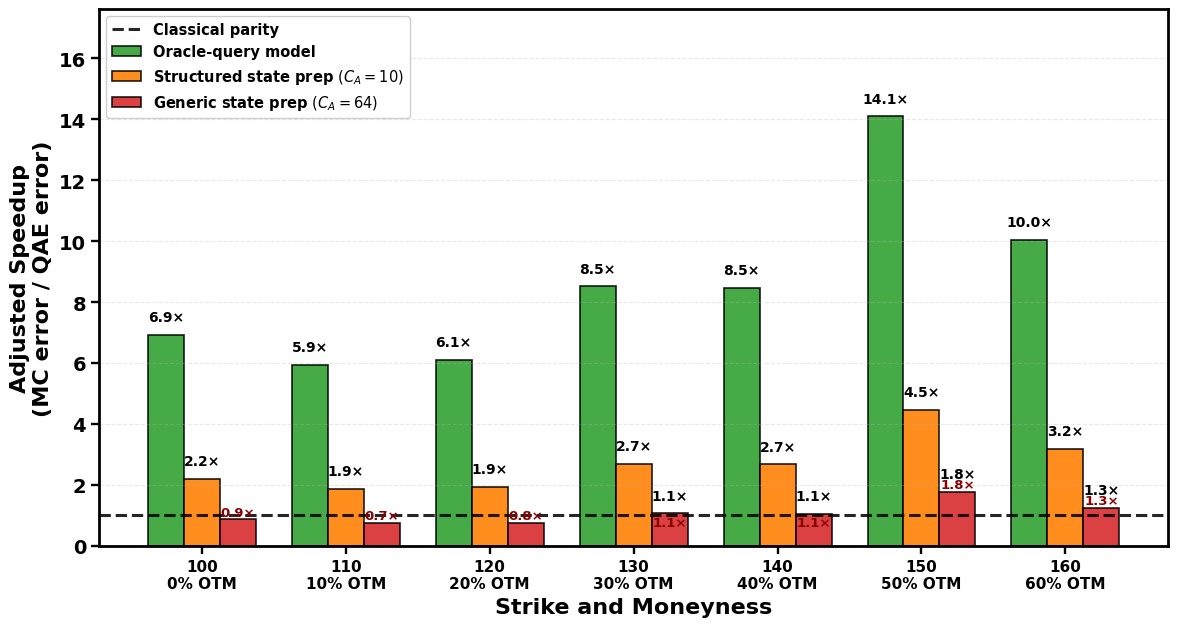


Saved: experiment_5_4_state_prep_cost.pdf / .png


In [14]:
# ==============================================================================
# EXPERIMENT 5.4: State-Preparation Cost Accounting
#
# Purpose:
#   Re-evaluate QAE advantage when oracle-query cost is replaced by a more
#   practical gate-adjusted cost model.
#
# This is a sensitivity analysis, not a hardware benchmark.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# REQUIREMENT
# ==============================================================================
# This assumes you have already run Experiment 5.2 and have a populated `results`
# list with fields:
#   K, otm, p, best_k, best_cost, best_speedup, best_mc_mean, best_qae_mean
# ==============================================================================

if "results" not in globals():
    raise RuntimeError("Run Experiment 5.2 first so the `results` list exists.")

# ==============================================================================
# COST MODELS
# ==============================================================================

cost_models = {
    "Oracle only": 1,
    r"Structured $C_A=10$": 10,
    r"Generic $C_A=64$": 64
}

# Monte Carlo error approximately scales as N^{-1/2}.
# If QAE effective cost is multiplied by C_A, then fair MC comparison should use
# C_A times more samples, reducing MC error by sqrt(C_A).
#
# Adjusted speedup:
#   speedup_adjusted = (MC error at expanded matched cost) / QAE error
#                    = (MC_error_oracle / sqrt(C_A)) / QAE_error
#                    = speedup_oracle / sqrt(C_A)

adjusted = []

for r_ in results:
    row = {
        "K": r_["K"],
        "otm": r_["otm"],
        "p": r_["p"],
        "best_k": r_["best_k"],
        "oracle_speedup": r_["best_speedup"]
    }

    for label, C_A in cost_models.items():
        row[label] = r_["best_speedup"] / np.sqrt(C_A)

    adjusted.append(row)

# ==============================================================================
# PRINT SUMMARY TABLE
# ==============================================================================

print("\n" + "="*105)
print("EXPERIMENT 5.4: STATE-PREPARATION COST ACCOUNTING")
print("="*105)
print(
    f"{'K':<6}{'OTM%':<8}{'p':<10}{'best_k':<9}"
    f"{'Oracle':<14}{'C_A=10':<14}{'C_A=64':<14}"
)
print("-"*105)

for row in adjusted:
    print(
        f"{row['K']:<6.0f}"
        f"{row['otm']:<8.0f}"
        f"{row['p']:<10.5f}"
        f"{row['best_k']:<9}"
        f"{row['Oracle only']:<14.2f}"
        f"{row[r'Structured $C_A=10$']:<14.2f}"
        f"{row[r'Generic $C_A=64$']:<14.2f}"
    )

print("="*105)
print(
    "\nInterpretation: oracle-query speedup survives practical accounting only when "
    "the adjusted speedup remains above 1×."
)

# ==============================================================================
# PLOTTING — CLEAN THESIS VERSION
# ==============================================================================

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.7,
    "ytick.major.width": 1.7,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 11,
})

Ks = [row["K"] for row in adjusted]
otm_vals = [row["otm"] for row in adjusted]
x = np.arange(len(adjusted))
w = 0.25

oracle_vals = [row["Oracle only"] for row in adjusted]
structured_vals = [row[r"Structured $C_A=10$"] for row in adjusted]
generic_vals = [row[r"Generic $C_A=64$"] for row in adjusted]

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.bar(
    x - w,
    oracle_vals,
    width=w,
    label="Oracle-query model",
    color="#2ca02c",
    alpha=0.88,
    edgecolor="black",
    linewidth=1.2
)

ax.bar(
    x,
    structured_vals,
    width=w,
    label=r"Structured state prep $(C_A=10)$",
    color="#ff7f00",
    alpha=0.88,
    edgecolor="black",
    linewidth=1.2
)

ax.bar(
    x + w,
    generic_vals,
    width=w,
    label=r"Generic state prep $(C_A=64)$",
    color="#d62728",
    alpha=0.88,
    edgecolor="black",
    linewidth=1.2
)

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=2.2,
    alpha=0.85,
    label="Classical parity"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{int(K)}\n{otm:.0f}% OTM" for K, otm in zip(Ks, otm_vals)],
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "Adjusted Speedup\n(MC error / QAE error)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Strike and Moneyness",
    fontsize=16,
    fontweight="bold"
)



# Add clean labels only above bars that remain above parity
for i, val in enumerate(oracle_vals):
    ax.text(
        x[i] - w,
        val + max(oracle_vals)*0.025,
        f"{val:.1f}×",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

for i, val in enumerate(structured_vals):
    if val > 1:
        ax.text(
            x[i],
            val + max(oracle_vals)*0.025,
            f"{val:.1f}×",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

for i, val in enumerate(generic_vals):
    if val > 1:
        ax.text(
            x[i] + w,
            val + max(oracle_vals)*0.025,
            f"{val:.1f}×",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Red labels — staggered lower to avoid overlap
red_offsets = [0.03, 0.03, 0.03, -0.08, -0.08, 0.03, 0.03]

for i, val in enumerate(generic_vals):
    ax.text(
        x[i] + w,
        val + red_offsets[i],
        f"{val:.1f}×",
        ha="center",
        va="bottom" if red_offsets[i] >= 0 else "top",
        fontsize=9.5,
        fontweight="bold",
        color="darkred"
    )
    
ax.set_ylim(0, max(oracle_vals) * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.28)

legend = ax.legend(fontsize=10.5, framealpha=0.95, loc="upper left")
for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()

plt.savefig("experiment_5_4_state_prep_cost.pdf", bbox_inches="tight")
plt.savefig("experiment_5_4_state_prep_cost.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: experiment_5_4_state_prep_cost.pdf / .png")